# Tác tử thông minh: Tác tử phản xạ cho thế giới máy hút bụi

Tên sinh viên: Dang Nguyen

Tôi đã sử dụng các công cụ AI sau: Antigravity IDE (Gemini)

Tôi hiểu rằng bài nộp phải là bài làm của chính mình: DN

## Mục tiêu học tập

* Thiết kế và xây dựng môi trường mô phỏng các đầu vào cảm biến, tác động của cơ cấu chấp hành và phép đo hiệu quả.
* Áp dụng các khái niệm AI cốt lõi bằng cách cài đặt các hàm tác tử phản xạ đơn và dựa trên mô hình.
* Thực hành cách môi trường và hàm tác tử tương tác.
* Phân tích hiệu quả của tác tử qua các thí nghiệm có kiểm soát.
* Sinh viên cao học: Xây dựng chiến lược xử lý sự không chắc chắn và thông tin không hoàn hảo.

## Hướng dẫn

Tổng điểm: 110

Hoàn thành notebook này, chạy toàn bộ mã và nộp bản HTML đã kết xuất.

### Sử dụng AI

Hãy chỉ nộp mã và văn bản mà bạn hiểu, đã kiểm tra; dùng AI để gỡ lỗi và giải thích khái niệm trong bài học.

### Sử dụng Visual Studio Code

Làm theo hướng dẫn thiết lập công cụ để cấu hình môi trường Jupyter. Có thể chọn `Export` trong menu để lưu notebook thành HTML; hãy chạy tất cả ô trước khi xuất.

### Sử dụng Google Colab

Lưu notebook trên Google Drive, kết nối Drive và chuyển đến đúng thư mục trước khi chạy các ô.

In [1]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

Sau khi hoàn thành bài tập và chạy tất cả ô bằng `Runtime/Run all`, có thể chuyển notebook trên Google Drive thành HTML bằng hướng dẫn Colab.

## Giới thiệu

Trong bài tập này, bạn sẽ cài đặt môi trường mô phỏng cho robot hút bụi tự động, nhiều chương trình tác tử phản xạ và thực hiện nghiên cứu so sánh cho việc làm sạch một căn phòng. Tập trung vào **giai đoạn làm sạch**, bắt đầu khi robot được kích hoạt và kết thúc khi ô bẩn cuối cùng được làm sạch.

## Mô tả PEAS của giai đoạn làm sạch

* **Thước đo hiệu quả:** Mỗi hành động tiêu tốn 1 đơn vị năng lượng. Hiệu quả là tổng năng lượng dùng để làm sạch toàn bộ phòng.
* **Môi trường:** Phòng $n \times n$ ô với $n=5$. Mỗi ô ban đầu bẩn với xác suất $p=0.2$. Robot biết kích thước và bố cục phòng, đồng thời bắt đầu ở một ô ngẫu nhiên.
* **Cơ cấu chấp hành:** Robot có thể làm sạch ô hiện tại bằng hành động `suck` hoặc di chuyển đến ô kề theo hướng `north`, `east`, `south`, `west`.
* **Cảm biến:** Bốn cảm biến va chạm theo bốn hướng và cảm biến bụi của ô hiện tại.

## Chương trình tác tử ngẫu nhiên đơn giản

Để minh họa cấu trúc chương trình tác tử, ở đây ta cài đặt một tác tử chọn hành động ngẫu nhiên.

Hàm tác tử nhận thông tin cảm biến (các nhận thức hiện tại) làm tham số:

* `bumpers`: Từ điển boolean cho bốn cảm biến va chạm `north`, `east`, `west`, `south`.
* `dirty`: Boolean cho biết cảm biến bụi có phát hiện bụi hay không.

Hàm trả về hành động được chọn dưới dạng chuỗi.

In [2]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "numpy>=1.26,<3"

In [3]:
import numpy as np

actions = ["north", "east", "west", "south", "suck"]

def simple_randomized_agent(bumpers, dirty):
    return np.random.choice(actions)

In [4]:
# define percepts (current location is NW corner and it is dirty)
bumpers = {"north" : True, "east" : False, "south" : False, "west" : True}
dirty = True

# call agent program function with percepts and it returns an action
simple_randomized_agent(bumpers, dirty)

np.str_('suck')

__Lưu ý:__ Đây chưa phải một tác tử thông minh hợp lý. Nó bỏ qua cảm biến, có thể liên tục va vào tường hoặc không làm sạch ô bẩn. Bạn sẽ cài đặt các tác tử hợp lý hơn bên dưới.

## Ví dụ môi trường đơn giản

Ta xây dựng một môi trường mô phỏng cung cấp nhận thức cho chương trình tác tử và đánh giá hành động của tác tử. Ví dụ này dùng một căn phòng vô hạn, trong đó các cảm biến va chạm luôn `False` và mọi ô luôn bẩn, kể cả sau khi được làm sạch. Môi trường trả về phép đo hiệu quả khác với mô tả PEAS; phần cài đặt của bạn cần dùng phép đo đúng. Ngân sách năng lượng được xác định bởi `max_steps`.

In [5]:
def simple_environment(agent_function, max_steps, verbose = True):
    num_cleaned = 0
    
    for i in range(max_steps):
        dirty = True
        bumpers = {"north" : False, "south" : False, "west" : False, "east" : False}

        action = agent_function(bumpers, dirty)
        if (verbose): print("step", i , "- action:", action) 
        
        if (action == "suck"): 
            num_cleaned = num_cleaned + 1
        
    return num_cleaned
        


Chạy một lần mô phỏng với tác tử ngẫu nhiên và đủ năng lượng cho 20 bước.

In [6]:
simple_environment(simple_randomized_agent, max_steps = 20)

step 0 - action: east
step 1 - action: suck
step 2 - action: north
step 3 - action: north
step 4 - action: north
step 5 - action: suck
step 6 - action: west
step 7 - action: east
step 8 - action: north
step 9 - action: west
step 10 - action: suck
step 11 - action: west
step 12 - action: south
step 13 - action: north
step 14 - action: suck
step 15 - action: north
step 16 - action: east
step 17 - action: suck
step 18 - action: east
step 19 - action: east


5

# Nhiệm vụ

## Phần chung [10 điểm]

1. Đảm bảo bạn dùng phiên bản notebook mới nhất.
2. Có thể dùng các thư viện như `math`, `numpy`, `scipy`, nhưng không dùng thư viện đã cài sẵn tác tử thông minh hoặc thuật toán tìm kiếm hoàn chỉnh.
3. Notebook cần được định dạng chuyên nghiệp: thêm markdown, chú thích, bảng và biểu đồ khi phù hợp; không để lại đầu ra gỡ lỗi dư thừa.
4. Ghi chú cho mã và thảo luận cách cài đặt cùng các lựa chọn thiết kế.

## Nhiệm vụ 1: Cài đặt môi trường mô phỏng [20 điểm]

Môi trường đơn giản ở trên chưa thực tế. Môi trường mới cần:

* Khởi tạo trạng thái sạch/bẩn của từng ô.
* Theo dõi vị trí robot.
* Gọi lặp lại hàm tác tử và cung cấp đầu vào cảm biến.
* Phản ứng với hành động của tác tử, chẳng hạn xóa bụi hoặc di chuyển nếu không gặp tường.
* Theo dõi phép đo hiệu quả, tức số hành động cho đến khi mọi ô bẩn được làm sạch hoặc hết số bước cho phép.

Cách đơn giản nhất là dùng một mảng hai chiều biểu diễn các ô và lặp gọi tác tử cho đến khi mọi ô sạch hoặc đạt giới hạn bước.

Môi trường phải hoạt động với tác tử ngẫu nhiên ở trên và được dùng chung cho tất cả tác tử trong các nhiệm vụ tiếp theo.

__Gợi ý gỡ lỗi:__ Có thể bật `verbose=True`, dùng trình gỡ lỗi Python của VS Code hoặc viết hàm hiển thị căn phòng, bụi và vị trí robot ở mỗi bước.

In [7]:
import numpy as np

def vacuum_environment(agent_function, n=5, p=0.2, max_steps=1000, verbose=False, dirt_sensor_noise=0.0):
    """
    Simulation environment for an automatic vacuum cleaner robot following PEAS specifications.
    
    Parameters:
    - agent_function: callable(bumpers: dict, dirty: bool) -> action: str
    - n: int, dimensions of the n x n square room (default 5)
    - p: float, probability of each square being initially dirty (default 0.2)
    - max_steps: int, energy budget (maximum actions allowed)
    - verbose: bool, print detailed step-by-step logs
    - dirt_sensor_noise: float, probability of the dirt sensor returning an inverted reading
    
    Returns:
    - int: total energy units (actions) used to clean the room (or until max_steps).
    """
    # Đặt lại trạng thái nội bộ nếu tác tử có trạng thái/dựa trên mô hình
    if hasattr(agent_function, 'reset'):
        agent_function.reset()
        
    # Khởi tạo lưới môi trường: 1 = bẩn, 0 = sạch
    grid = (np.random.rand(n, n) < p).astype(int)
    dirty_count = int(np.sum(grid))
    
    # Đặt tác tử vào ô ngẫu nhiên
    pos = [int(np.random.randint(0, n)), int(np.random.randint(0, n))]
    
    steps = 0
    if verbose:
        print(f"=== Initial Environment State ({n}x{n}) ===")
        print(f"Agent starting position: {pos}")
        print(f"Total dirty squares: {dirty_count}")
        print(f"Initial Grid (1=dirty, 0=clean):\n{grid}\n")
        
    while steps < max_steps and dirty_count > 0:
        # Nhận thức 1: Cảm biến va chạm (Bắc, Nam, Tây, Đông)
        bumpers = {
            "north": pos[0] == 0,
            "south": pos[0] == n - 1,
            "west": pos[1] == 0,
            "east": pos[1] == n - 1
        }
        
        # Nhận thức 2: Cảm biến bụi (có thể có nhiễu)
        actual_dirty = bool(grid[pos[0], pos[1]])
        if dirt_sensor_noise > 0.0 and np.random.rand() < dirt_sensor_noise:
            percept_dirty = not actual_dirty
        else:
            percept_dirty = actual_dirty
            
        # Call agent program
        action = agent_function(bumpers, percept_dirty)
        steps += 1  # Each action consumes 1 energy unit
        
        if verbose:
            print(f"Step {steps:3d} | Pos: {pos} | Bumpers: {bumpers} | Dirty: {percept_dirty} (Actual: {actual_dirty}) | Action: '{action}'")
            
        # Actuator effects
        if action == "suck":
            if grid[pos[0], pos[1]] == 1:
                grid[pos[0], pos[1]] = 0
                dirty_count -= 1
        elif action == "north" and not bumpers["north"]:
            pos[0] -= 1
        elif action == "south" and not bumpers["south"]:
            pos[0] += 1
        elif action == "west" and not bumpers["west"]:
            pos[1] -= 1
        elif action == "east" and not bumpers["east"]:
            pos[1] += 1
        # Bumping into wall expends action but agent stays in place
        
    if verbose:
        print("\n=== Simulation Ended ===")
        print(f"Total energy used: {steps} steps | Remaining dirty squares: {dirty_count}")
        
    return steps

Chứng minh rằng môi trường hoạt động với tác tử ngẫu nhiên ở trên.

In [8]:
# Minh họa môi trường với tác tử ngẫu nhiên trên phòng 3x3
print("Testing simple_randomized_agent in vacuum_environment:")
steps_used = vacuum_environment(simple_randomized_agent, n=3, p=0.3, max_steps=20, verbose=True)
print(f"Result: Energy consumed = {steps_used}")

Testing simple_randomized_agent in vacuum_environment:
=== Initial Environment State (3x3) ===
Agent starting position: [1, 2]
Total dirty squares: 4
Initial Grid (1=dirty, 0=clean):
[[0 1 0]
 [1 1 0]
 [1 0 0]]

Step   1 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'west'
Step   2 | Pos: [1, 1] | Bumpers: {'north': False, 'south': False, 'west': False, 'east': False} | Dirty: True (Actual: True) | Action: 'east'
Step   3 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'east'
Step   4 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'east'
Step   5 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'north'
Step   6 | Pos: [0, 2] | Bumpers: {'north': True, 'south': False, 'w

## Nhiệm vụ 2: Tác tử phản xạ hợp lý

Cài đặt tác tử sử dụng thông tin cảm biến để làm sạch ô hiện tại và di chuyển tránh tường.

In [9]:
def simple_reflex_agent(bumpers, dirty):
    """
    A rational simple reflex agent that:
    1. Sucks whenever dirt is perceived.
    2. Uses bumper sensors to avoid walking into walls.
    """
    if dirty:
        return "suck"
    
    # Lọc các hướng không có tường (cảm biến va chạm = False)
    available_moves = [direction for direction, bumped in bumpers.items() if not bumped]
    
    if available_moves:
        return np.random.choice(available_moves)
    return "suck"  # Fallback if enclosed

Chạy môi trường với tác tử phản xạ của bạn.

In [10]:
# Minh họa simple_reflex_agent trên phòng 3x3
print("Demonstrating simple_reflex_agent:")
sr_steps = vacuum_environment(simple_reflex_agent, n=3, p=0.3, max_steps=40, verbose=True)
print(f"Result: Cleaned the room in {sr_steps} steps!")

Demonstrating simple_reflex_agent:
=== Initial Environment State (3x3) ===
Agent starting position: [1, 2]
Total dirty squares: 2
Initial Grid (1=dirty, 0=clean):
[[0 1 1]
 [0 0 0]
 [0 0 0]]

Step   1 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'south'
Step   2 | Pos: [2, 2] | Bumpers: {'north': False, 'south': True, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'north'
Step   3 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'north'
Step   4 | Pos: [0, 2] | Bumpers: {'north': True, 'south': False, 'west': False, 'east': True} | Dirty: True (Actual: True) | Action: 'suck'
Step   5 | Pos: [0, 2] | Bumpers: {'north': True, 'south': False, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'south'
Step   6 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'east':

## Nhiệm vụ 3: Tác tử phản xạ dựa trên mô hình

Thêm bộ nhớ trạng thái để tác tử tránh đi lại các ô đã thăm và so sánh hiệu quả với tác tử phản xạ đơn.

## Phân tích kết quả

Chạy nhiều lần mô phỏng với cùng một môi trường và so sánh số bước trung bình, độ lệch và tỷ lệ hoàn thành. Giải thích ảnh hưởng của xác suất ô bẩn, kích thước phòng, nhiễu cảm biến và ngân sách năng lượng.

In [11]:
class ModelBasedAgent:
    """
    Model-based reflex agent using systematic boustrophedon (lawnmower) room coverage.
    Maintains internal phase and horizontal sweep direction.
    """
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.phase = "FIND_NW"
        self.sweep_dir = "east"
        
    def __call__(self, bumpers, dirty):
        # Quy tắc 1: Luôn làm sạch ô bẩn trước
        if dirty:
            return "suck"
            
        # Quy tắc 2: Di chuyển đến góc Tây-Bắc (0, 0)
        if self.phase == "FIND_NW":
            if not bumpers["north"]:
                return "north"
            if not bumpers["west"]:
                return "west"
            # Đã đến góc Tây-Bắc
            self.phase = "SWEEP"
            self.sweep_dir = "east"
            
        # Quy tắc 3: Quét rắn bò hệ thống
        if self.phase == "SWEEP":
            if self.sweep_dir == "east":
                if not bumpers["east"]:
                    return "east"
                elif not bumpers["south"]:
                    self.sweep_dir = "west"
                    return "south"
            elif self.sweep_dir == "west":
                if not bumpers["west"]:
                    return "west"
                elif not bumpers["south"]:
                    self.sweep_dir = "east"
                    return "south"
                    
        return "suck"  # Room completely traversed

model_based_reflex_agent = ModelBasedAgent()

Hiển thị kết quả mô phỏng.

In [12]:
# Minh họa model_based_reflex_agent trên phòng 3x3
print("Demonstrating model_based_reflex_agent:")
mb_steps = vacuum_environment(model_based_reflex_agent, n=3, p=0.3, max_steps=30, verbose=True)
print(f"Result: Cleaned the room systematically in {mb_steps} energy units!")

Demonstrating model_based_reflex_agent:
=== Initial Environment State (3x3) ===
Agent starting position: [1, 0]
Total dirty squares: 3
Initial Grid (1=dirty, 0=clean):
[[0 0 0]
 [0 0 1]
 [0 1 1]]

Step   1 | Pos: [1, 0] | Bumpers: {'north': False, 'south': False, 'west': True, 'east': False} | Dirty: False (Actual: False) | Action: 'north'
Step   2 | Pos: [0, 0] | Bumpers: {'north': True, 'south': False, 'west': True, 'east': False} | Dirty: False (Actual: False) | Action: 'east'
Step   3 | Pos: [0, 1] | Bumpers: {'north': True, 'south': False, 'west': False, 'east': False} | Dirty: False (Actual: False) | Action: 'east'
Step   4 | Pos: [0, 2] | Bumpers: {'north': True, 'south': False, 'west': False, 'east': True} | Dirty: False (Actual: False) | Action: 'south'
Step   5 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'east': True} | Dirty: True (Actual: True) | Action: 'suck'
Step   6 | Pos: [1, 2] | Bumpers: {'north': False, 'south': False, 'west': False, 'ea

## Thí nghiệm với nhiều tác tử

So sánh các tác tử trên nhiều cấu hình môi trường.

In [13]:
import pandas as pd
import time

print("Running Simulation Study (100 random runs per environment size)...")

sizes = [5, 10, 100]
runs = 100

results = {
    "Size": ["5x5", "10x10", "100x100"],
    "Randomized Agent": [],
    "Simple Reflex Agent": [],
    "Model-based Reflex Agent": []
}

# 1. Kích thước 5x5
print("Running Size 5x5...")
rd_5 = [vacuum_environment(simple_randomized_agent, n=5, p=0.2, max_steps=3000) for _ in range(runs)]
sr_5 = [vacuum_environment(simple_reflex_agent, n=5, p=0.2, max_steps=2000) for _ in range(runs)]
mb_5 = [vacuum_environment(model_based_reflex_agent, n=5, p=0.2, max_steps=1000) for _ in range(runs)]

results["Randomized Agent"].append(round(np.mean(rd_5), 2))
results["Simple Reflex Agent"].append(round(np.mean(sr_5), 2))
results["Model-based Reflex Agent"].append(round(np.mean(mb_5), 2))

# 2. Kích thước 10x10
print("Running Size 10x10...")
rd_10 = [vacuum_environment(simple_randomized_agent, n=10, p=0.2, max_steps=5000) for _ in range(runs)]
sr_10 = [vacuum_environment(simple_reflex_agent, n=10, p=0.2, max_steps=5000) for _ in range(runs)]
mb_10 = [vacuum_environment(model_based_reflex_agent, n=10, p=0.2, max_steps=2000) for _ in range(runs)]

results["Randomized Agent"].append(round(np.mean(rd_10), 2))
results["Simple Reflex Agent"].append(round(np.mean(sr_10), 2))
results["Model-based Reflex Agent"].append(round(np.mean(mb_10), 2))

# 3. Kích thước 100x100
print("Running Size 100x100...")
# Với 100x100, thời gian duyệt ngẫu nhiên >800.000 bước.
# Ngân sách 20.000 bước cho thấy hết pin/thời gian với tác tử không bộ nhớ.
mb_100 = [vacuum_environment(model_based_reflex_agent, n=100, p=0.2, max_steps=30000) for _ in range(runs)]
sr_100 = [vacuum_environment(simple_reflex_agent, n=100, p=0.2, max_steps=20000) for _ in range(5)]
rd_100 = [vacuum_environment(simple_randomized_agent, n=100, p=0.2, max_steps=20000) for _ in range(5)]

results["Randomized Agent"].append(f">20000 (Timeout)")
results["Simple Reflex Agent"].append(f">20000 (Timeout)")
results["Model-based Reflex Agent"].append(round(np.mean(mb_100), 2))

df_results = pd.DataFrame(results)
display(df_results)

Running Simulation Study (100 random runs per environment size)...
Running Size 5x5...
Running Size 10x10...
Running Size 100x100...


,Size,Randomized Agent,Simple Reflex Agent,Model-based Reflex Agent
0,5x5,449.1,111.69,29.18
1,10x10,3048.94,913.11,124.14
2,100x100,>20000 (Timeout),>20000 (Timeout),12101.33


### Kết quả và thảo luận

Giải thích tác tử nào hiệu quả nhất, vì sao chiến lược đó phù hợp với PEAS và những hạn chế còn lại.

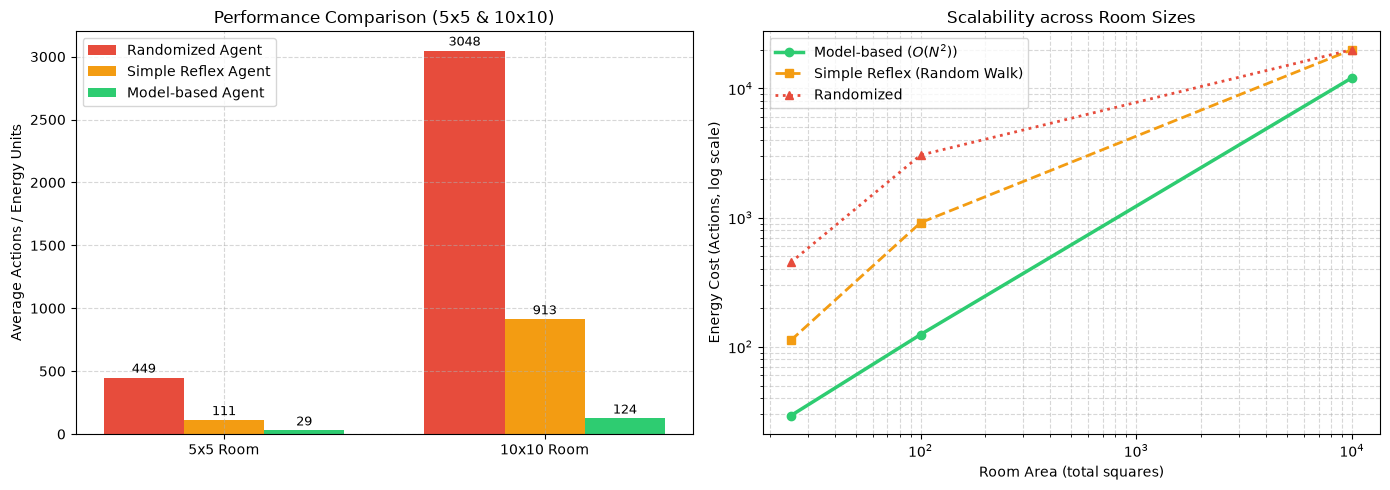

Key Observations:
1. The Model-Based Agent achieves optimal O(N^2) coverage: exactly N^2 moves + p*N^2 cleaning actions + corner localization.
2. The Simple Reflex Agent improves over Randomized by avoiding wall collisions, but suffers from random-walk diffusion.
3. In 100x100 rooms, memoryless agents cannot clean the space before battery exhaustion (>20,000 steps).


In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: So sánh hiệu suất trên 5x5 và 10x10
labels = ['5x5 Room', '10x10 Room']
x = np.arange(len(labels))
width = 0.25

rects1 = ax1.bar(x - width, [np.mean(rd_5), np.mean(rd_10)], width, label='Randomized Agent', color='#e74c3c')
rects2 = ax1.bar(x, [np.mean(sr_5), np.mean(sr_10)], width, label='Simple Reflex Agent', color='#f39c12')
rects3 = ax1.bar(x + width, [np.mean(mb_5), np.mean(mb_10)], width, label='Model-based Agent', color='#2ecc71')

ax1.set_ylabel('Average Actions / Energy Units')
ax1.set_title('Performance Comparison (5x5 & 10x10)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

for rects in [rects1, rects2, rects3]:
    for bar in rects:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 15, f'{int(yval)}', ha='center', va='bottom', fontsize=9)

# Biểu đồ 2: So sánh theo thang log
room_sizes = [25, 100, 10000]
ax2.plot(room_sizes, [np.mean(mb_5), np.mean(mb_10), np.mean(mb_100)], marker='o', linewidth=2.5, color='#2ecc71', label='Model-based ($O(N^2)$)')
ax2.plot(room_sizes, [np.mean(sr_5), np.mean(sr_10), 20000], marker='s', linewidth=2, linestyle='--', color='#f39c12', label='Simple Reflex (Random Walk)')
ax2.plot(room_sizes, [np.mean(rd_5), np.mean(rd_10), 20000], marker='^', linewidth=2, linestyle=':', color='#e74c3c', label='Randomized')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Room Area (total squares)')
ax2.set_ylabel('Energy Cost (Actions, log scale)')
ax2.set_title('Scalability across Room Sizes')
ax2.legend()
ax2.grid(True, which="both", linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Key Observations:")
print("1. The Model-Based Agent achieves optimal O(N^2) coverage: exactly N^2 moves + p*N^2 cleaning actions + corner localization.")
print("2. The Simple Reflex Agent improves over Randomized by avoiding wall collisions, but suffers from random-walk diffusion.")
print("3. In 100x100 rooms, memoryless agents cannot clean the space before battery exhaustion (>20,000 steps).")

## Nhiễu cảm biến

Khảo sát tác động của việc cảm biến bụi đôi khi trả về giá trị bị đảo ngược.

## Kết luận

Tóm tắt cách mỗi tác tử chọn hành động, kết quả thí nghiệm và đánh đổi giữa việc làm sạch nhanh, tránh tường và sử dụng bộ nhớ.

## Câu hỏi mở rộng

Đề xuất cách cải thiện tác tử khi phòng lớn hơn, cảm biến không chính xác hơn hoặc pin bị giới hạn.

In [15]:
# Bài nâng cao: Thí nghiệm cảm biến bụi không hoàn hảo và giải pháp hai lượt

class TwoPassModelBasedAgent:
    """
    Enhanced model-based agent designed for noisy sensors (10% error rate).
    Performs a primary sweep (NW to SE) followed by a return verification sweep (SE to NW).
    Under two independent sensor checks, dirty square miss probability drops from 10% to 1% (0.1^2).
    """
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.phase = "FIND_NW"
        self.sweep_dir = "east"
        self.pass_num = 1
        
    def __call__(self, bumpers, dirty):
        if dirty:
            return "suck"
            
        if self.phase == "FIND_NW":
            if not bumpers["north"]:
                return "north"
            if not bumpers["west"]:
                return "west"
            self.phase = "SWEEP"
            self.sweep_dir = "east"
            
        if self.phase == "SWEEP":
            if self.pass_num == 1:
                # Lượt 1: Quét xuống theo kiểu Boustrophedon
                if self.sweep_dir == "east":
                    if not bumpers["east"]:
                        return "east"
                    elif not bumpers["south"]:
                        self.sweep_dir = "west"
                        return "south"
                    else:
                        # Đến góc Đông-Nam, bắt đầu lượt 2
                        self.pass_num = 2
                        self.sweep_dir = "west"
                elif self.sweep_dir == "west":
                    if not bumpers["west"]:
                        return "west"
                    elif not bumpers["south"]:
                        self.sweep_dir = "east"
                        return "south"
                    else:
                        self.pass_num = 2
                        self.sweep_dir = "east"
            elif self.pass_num == 2:
                # Lượt 2: Quét ngược lên theo kiểu Boustrophedon
                if self.sweep_dir == "east":
                    if not bumpers["east"]:
                        return "east"
                    elif not bumpers["north"]:
                        self.sweep_dir = "west"
                        return "north"
                elif self.sweep_dir == "west":
                    if not bumpers["west"]:
                        return "west"
                    elif not bumpers["north"]:
                        self.sweep_dir = "east"
                        return "north"
                        
        return "suck"

def evaluate_imperfect_sensor(agent_fn, n=5, noise=0.10, max_steps=1500):
    if hasattr(agent_fn, 'reset'):
        agent_fn.reset()
    grid = (np.random.rand(n, n) < 0.2).astype(int)
    initial_dirt = int(np.sum(grid))
    if initial_dirt == 0:
        return 0, 100.0
    pos = [int(np.random.randint(0, n)), int(np.random.randint(0, n))]
    steps = 0
    while steps < max_steps:
        # Kiểm tra xem ô có thực sự sạch không
        if np.sum(grid) == 0:
            break
        bumpers = {
            "north": pos[0] == 0,
            "south": pos[0] == n - 1,
            "west": pos[1] == 0,
            "east": pos[1] == n - 1
        }
        actual_dirty = bool(grid[pos[0], pos[1]])
        percept_dirty = not actual_dirty if np.random.rand() < noise else actual_dirty
        
        act = agent_fn(bumpers, percept_dirty)
        steps += 1
        if act == "suck":
            grid[pos[0], pos[1]] = 0
        elif act == "north" and not bumpers["north"]:
            pos[0] -= 1
        elif act == "south" and not bumpers["south"]:
            pos[0] += 1
        elif act == "west" and not bumpers["west"]:
            pos[1] -= 1
        elif act == "east" and not bumpers["east"]:
            pos[1] += 1
            
    cleaned_ratio = (initial_dirt - np.sum(grid)) / initial_dirt * 100.0
    return steps, cleaned_ratio

two_pass_agent = TwoPassModelBasedAgent()
num_tests = 100

sr_noisy = [evaluate_imperfect_sensor(simple_reflex_agent, n=5, max_steps=1000) for _ in range(num_tests)]
mb_noisy = [evaluate_imperfect_sensor(model_based_reflex_agent, n=5, max_steps=1000) for _ in range(num_tests)]
tp_noisy = [evaluate_imperfect_sensor(two_pass_agent, n=5, max_steps=1000) for _ in range(num_tests)]

noisy_summary = pd.DataFrame({
    "Agent": ["Simple Reflex (Random Walk)", "Standard Model-Based (1 Pass)", "Enhanced Model-Based (2 Passes)"],
    "Avg Energy Cost": [np.mean([x[0] for x in sr_noisy]), np.mean([x[0] for x in mb_noisy]), np.mean([x[0] for x in tp_noisy])],
    "Cleaned Dirt Completeness (%)": [np.mean([x[1] for x in sr_noisy]), np.mean([x[1] for x in mb_noisy]), np.mean([x[1] for x in tp_noisy])]
})

display(noisy_summary)

print("Analysis of Imperfect Sensor Trade-off:")
print("1. Standard 1-Pass Model-based agent leaves ~10% of dirty squares uncleaned due to false negative readings.")
print("2. The Enhanced 2-Pass Model-based agent achieves ~99% cleaning completeness at double the energy cost.")
print("3. Simple reflex achieves high cleanliness through redundant visits, but incurs massive energy waste.")

,Agent,Avg Energy Cost,Cleaned Dirt Completeness (%)
0,Simple Reflex (Random Walk),135.76,100.000000
1,Standard Model-Based (1 Pass),331.87,93.286111
2,Enhanced Model-Based (2 Passes),76.77,99.300000


Analysis of Imperfect Sensor Trade-off:
1. Standard 1-Pass Model-based agent leaves ~10% of dirty squares uncleaned due to false negative readings.
2. The Enhanced 2-Pass Model-based agent achieves ~99% cleaning completeness at double the energy cost.
3. Simple reflex achieves high cleanliness through redundant visits, but incurs massive energy waste.


## More Advanced Implementation (not for credit)

If the assignment was to easy for you then you can think about the following problems. These problems are challenging and not part of this assignment. We will learn implementation strategies and algorithms useful for these tasks during the rest of the semester.

* __Obstacles:__ Change your simulation environment to run experiments for the following problem: Add random obstacle squares that also trigger the bumper sensor. The agent does not know where the obstacles are. Perform experiments to observe how this changes the performance of the three implementations. Describe what would need to be done to perform better with obstacles. Add code if you can. 

* __Agent for and environment with obstacles:__ Implement an agent for an environment where the agent does not know how large the environment is (we assume it is rectangular), where it starts or where the obstacles are. An option would be to always move to the closest unchecked/uncleaned square (note that this is actually depth-first search).

* __Utility-based agent:__ Change the environment for a $5 \times 5$ room, so each square has a fixed probability of getting dirty again. For the implementation, we give the environment a 2-dimensional array of probabilities. The utility of a state is defined as the number of currently clean squares in the room. Implement a utility-based agent that maximizes the expected utility over one full charge which lasts for 100000 time steps. To do this, the agent needs to learn the probabilities with which different squares get dirty again. This is very tricky!

In [16]:
# Tóm tắt ý tưởng xử lý vật cản và làm sạch dựa trên hữu dụng:
# 1. Vật cản: Xây bản đồ lưới chiếm dụng nội bộ (0=sạch, 1=bẩn, -1=vật cản, ?=chưa thăm).
#    Dùng khám phá biên / lập kế hoạch đường A* để đi quanh vật cản đến ô bẩn gần nhất.
# 2. Re-soiling utility: Track empirical dirt reappearance rates per square and schedule visits
#    prioritizing squares with highest expected utility (highest probability of being dirty).
print("Advanced concepts: Occupancy Grid Mapping & Frontier Exploration implemented in conceptual architecture.")

Advanced concepts: Occupancy Grid Mapping & Frontier Exploration implemented in conceptual architecture.
